#1. Tarea 1: Importación de librerías, carga del dataset en un data frame y muestra inicial.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import  train_test_split,StratifiedKFold
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay,precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from google.colab import files


Funciones

In [40]:
def buscarCeros(lista):
    for i in lista:
        print(i)
        print((breastcancer[breastcancer[i]==0]).shape[0])
        print("-------------")

def borrarFilasCero(df,columna):
    df=df[df[columna]!=0]
    return df

1.1. Carga el dataset en un dataframe llamado datos.

In [41]:

url = "https://raw.githubusercontent.com/santibachi0/dataset_breast_cancer_wisconsin_data/main/data.csv"

datos=pd.read_csv(url,sep=",") #El dataset original tiene una coma final en la primera fila por lo que genera una columna vacía, se debe quitar esa coma


1.2. Muestra el dataset.

In [42]:
print(datos.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

1.3. Muestra un resumen estadístico del dataset de forma numérica

In [43]:
print(datos.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

1.4. Muestra al menos tres gráficos estadísticos sobre el dataset, elige los que creas más
oportunos.

Gráfico 1, Muestra el número de casos malignos y benignos

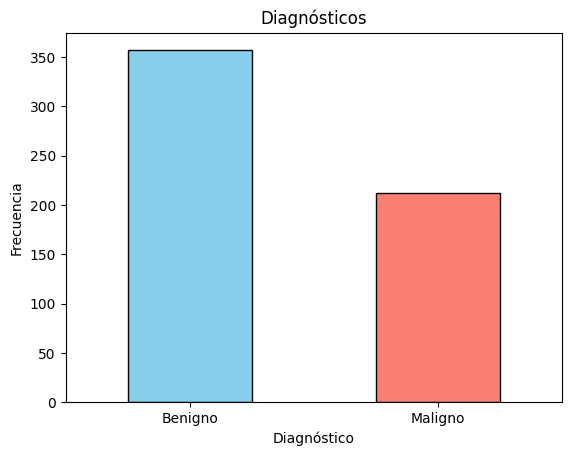

In [44]:
datos["diagnosis"].value_counts().rename({"B": "Benigno", "M": "Maligno"}).plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black",rot=0)

plt.xlabel("Diagnóstico")
plt.ylabel("Frecuencia")
plt.title("Diagnósticos")

plt.show()

Gráfico 2, Histograma que muestra el radio promedio en comparación con el diagnostico si es maligno o beligno, se observa una cierta diferencia entre las comparaciones

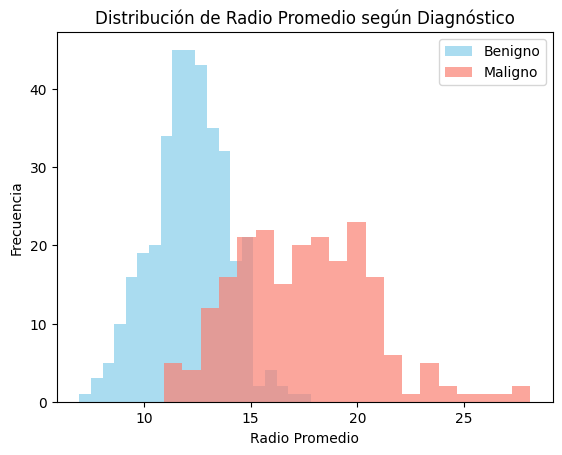

In [45]:
benigno = datos[datos["diagnosis"] == "B"]
maligno = datos[datos["diagnosis"] == "M"]

plt.hist(benigno["radius_mean"], bins=20, alpha=0.7, label="Benigno", color="skyblue")
plt.hist(maligno["radius_mean"], bins=20, alpha=0.7, label="Maligno", color="salmon")
plt.xlabel("Radio Promedio")
plt.ylabel("Frecuencia")
plt.title("Distribución de Radio Promedio según Diagnóstico")
plt.legend()
plt.show()

Gráfico 3, Muestra un diagrama de dispersión que muestra la relación entre concavity_mean (concavidad promedio) y smoothness_mean (suavidad promedio).
Las muestras benignas se muestran en azul  y las malignas en rojo. También se aprecia cierta diferencia clara entre los malignos y bnignos.

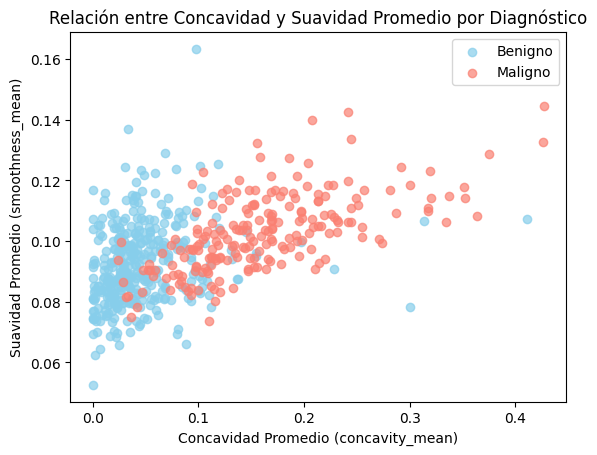

In [46]:
plt.scatter(benigno["concavity_mean"], benigno["smoothness_mean"], color="skyblue", label="Benigno", alpha=0.7)
plt.scatter(maligno["concavity_mean"], maligno["smoothness_mean"], color="salmon", label="Maligno", alpha=0.7)

plt.xlabel("Concavidad Promedio (concavity_mean)")
plt.ylabel("Suavidad Promedio (smoothness_mean)")
plt.title("Relación entre Concavidad y Suavidad Promedio por Diagnóstico")
plt.legend()

plt.show()

#2. Tarea 2: Preparación de los datos:

2.1. Comprueba que todos los datos cumplen los requisitos indicados. Si algún dato no lo
cumple, elimina la fila completa.

In [47]:
breastcancer=datos.copy()

print(breastcancer.info())
print(datos.shape)
print(breastcancer["diagnosis"].value_counts())

lista=["radius_mean",
"perimeter_mean", "area_mean", "radius_worst", "perimeter_worst", "area_worst",
"compactness_mean", "concavity_mean", "concave points_mean", "smoothness_mean",
"fractal_dimension_mean"]

buscarCeros(lista)
breastcancer=borrarFilasCero(breastcancer,"concavity_mean")
breastcancer=borrarFilasCero(breastcancer,"concave points_mean")

print(breastcancer.info())
print(datos.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

2.2. Modifica o mapea los tipos que creas oportuno.

In [48]:
breastcancer["diagnosis"]=breastcancer["diagnosis"].map({"M":1,"B":0})

2.3. Escala los atributos por el método de estandarización que creas más oportuno. Ten
en cuenta el clasificador bayesiano que vayas a usar después.

In [49]:
X = breastcancer.drop(columns=["diagnosis", "id"])
y = breastcancer["diagnosis"]


numeric_cols = X.select_dtypes(include=['float64']).columns.to_list() #El id no me sirve para entrenar
preprocesado=ColumnTransformer([('scale', MinMaxScaler(), numeric_cols)],remainder='passthrough')
X_scaled = preprocesado.fit_transform(X)
print(X_scaled.shape)

(556, 30)


#3. Tarea 3: Preparación de los conjuntos de entrenamiento y de test

3.1. Calcula la correlación que existe entre las distintas características y muéstra los
resultados de forma gráfica.

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

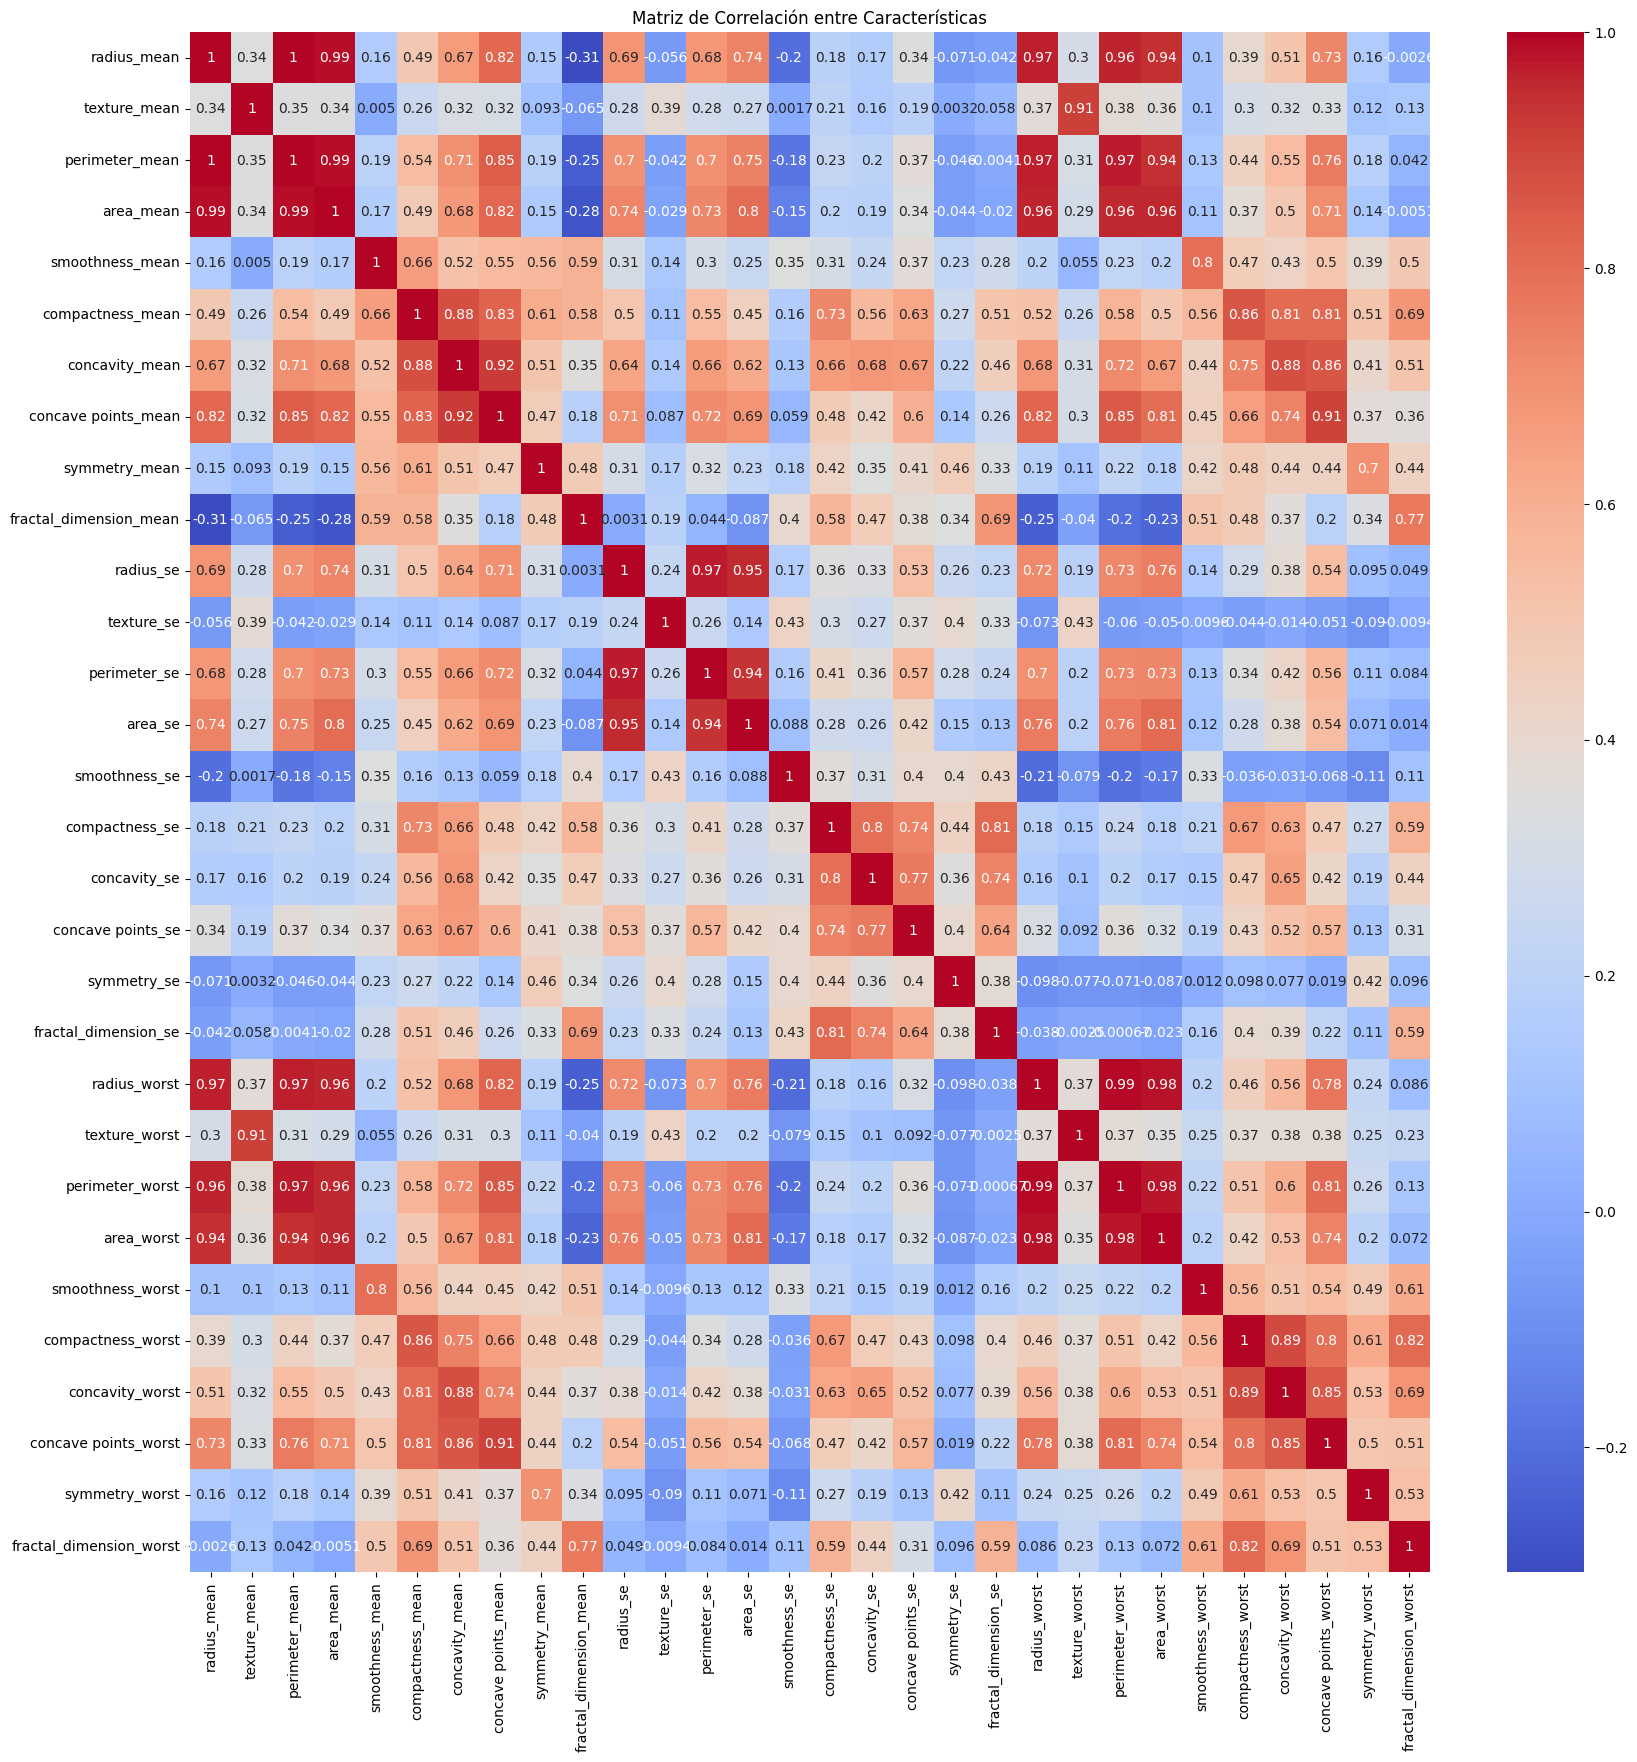

In [50]:
X_df = pd.DataFrame(X, columns=numeric_cols)
print(X_df.head())

correlation_matrix = X_df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación entre Características")
plt.show()

3.2. Elige con qué características vas a entrenar el modelo. Explica justificadamente tu
elección en un cuadro de texto del cuaderno

Hay varias características que se relacionan entre sí, por ello he elegido una de cada grupo correlacionado para así no crear redundancia.
He elegido radius_worst del grupo (radius_worst, perimeter_worst, area_worst).
y concave_points_mean. Luego también he elegido dos características una que tiene poca correlación con las demás(texture_mean) y otra que tiene una correlación media.( smoothness_mean) para aportar diversidad.


In [51]:
caracteristicas = ["radius_worst", "concave points_mean", "texture_mean", "smoothness_mean"]
X = X_df[caracteristicas]
print(X.shape)

(556, 4)


Se creará un conjunto de entrenamiento con el 80% de las observaciones y un conjunto de
test con el 20% de los valores. Utiliza una semilla aleatoria para obtener siempre los mismos
resultados, eso te facilitará las pruebas.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9, stratify=y)


# Tarea 4: Validación cruzada y elección de los parámetros

Métrica de distancia.
● Método de nº de vecinos, o método del radio.
● Valor de k (nº de vecinos), o de r (radio)
● Valor de weight (uniform o distance).

In [53]:

# Utilizo esto ya que voy a usar grid_search para que pruebe con todas estas posibilidades y no tener que hacerlo de forma manual
param_grid = {
    'n_neighbors': range(1, 21),  # Valores de k
    'weights': ['uniform', 'distance'],  # Pesos
    'metric': ['euclidean', 'manhattan']  # Métricas
}

#Ya que es una clasificación uso Classifier y no KNeighborsRegressor
#No uso RadiusNeighborsClassifier ya que los datos tienen unas
#caráctiristicas relativamente correlacionadas y se ha estandarizado
#por lo que tiene más sentido usar este
knn = KNeighborsClassifier()

#Utilizo este cv para que haya una cantidad proporcional en el entrenamiento(3 vueltas) tanto de 1 y 0
cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=7)


grid_search = GridSearchCV(knn, param_grid, cv=cv, scoring='f1')


grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=7, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 21),
                         'weights': ['uniform', 'distance']},
             scoring='f1')

#5. Tarea 5: Muestra los resultados del modelo seleccionado

5.1. Se mostrarán los valores numéricos de eficacia

In [54]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Mejores parámetros encontrados:", best_params)
print("Mejor puntuación F1 (validación cruzada):", best_score)

# Evaluar el modelo con los mejores parámetros en el conjunto de prueba
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

# Calcula métricas de evaluación
precision = precision_score(y_test, y_pred,zero_division=0)
recall_malignos = recall_score(y_test, y_pred,zero_division=0)
recall_benignos = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
f1 = f1_score(y_test, y_pred,zero_division=0)


print(f"Precisión: {precision}")
print(f"Recall Malignos: {recall_malignos}")
print(f"Recall Benignos: {recall_benignos}")
print(f"F1-Score: {f1}")
print()

Mejores parámetros encontrados: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejor puntuación F1 (validación cruzada): 0.9153212149138872
Precisión: 1.0
Recall Malignos: 0.8837209302325582
Recall Benignos: 1.0
F1-Score: 0.9382716049382716



5.2. Se mostrará una matriz de confusión gráfica.

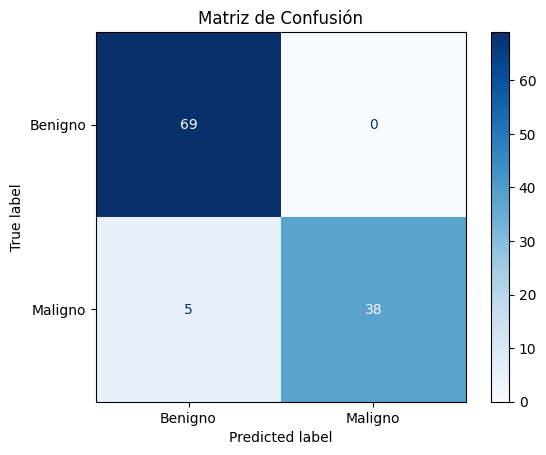

In [55]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

5.3. Se creará un dataframe llamado predicciones donde aparezcan los valores del
conjunto de test con todas sus columnas y dos columnas más añadidas al final: La
columna prediccion, con el valor predicho del resultado y la columna acierto, que
contendrá un 0 si la predicción es distinta al resultado real y un 1 si es igual.

In [56]:
predicciones = X_test.copy()
predicciones["diagnosis"] = y_test.values
predicciones["prediccion"] = y_pred
predicciones["acierto"] = (predicciones["diagnosis"] == predicciones["prediccion"]).astype(int)

print(predicciones.head())

     radius_worst  concave points_mean  texture_mean  smoothness_mean  \
254         25.70              0.08591         19.33          0.10350   
417         23.17              0.08481         21.08          0.11200   
137         12.32              0.02875         15.39          0.09639   
128         16.11              0.08534         16.39          0.11500   
503         30.79              0.10030         19.83          0.09342   

     diagnosis  prediccion  acierto  
254          1           1        1  
417          1           1        1  
137          0           0        1  
128          0           0        1  
503          1           1        1  


#6. Tarea 6: Guarda la predicción en un fichero csv

6.1. Guarda el dataframe predicciones en tu disco local, con el nombre
predicciones3_nombre_apellido1_apellido2.csv.

In [ ]:
predicciones.to_csv("predicciones3.csv", index=False)
files.download("predicciones3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>